# Data Quality Assessment and Visualization: Healthcare Dataset

**Objective:**  
Perform data validation, cleaning, and reporting on a healthcare dataset (patient admissions, demographics, diagnoses).  

**Skills Demonstrated:**  
- Python (Pandas, NumPy)  
- Data QA and Validation  
- Data Cleaning and Transformation  
- Visualization (Matplotlib, Seaborn)  
- Reporting and Documentation  

**Dataset:** Synthetic Healthcare Admissions Dataset (Kaggle)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("train.csv")  
df.head() #Quick look into data

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
0,80,1.0,7.0,0.0,37303.079537,0.0,0.0,0.0
1,80,0.0,0.0,4.0,19201.947163,2.0,0.0,2.0
2,52,0.0,5.0,5.0,16161.339916,1.0,4.0,0.0
3,56,0.0,7.0,1.0,30310.878492,1.0,1.0,0.0
4,80,0.0,4.0,2.0,45593.675180,2.0,0.0,2.0


In [9]:
df.info()
df.describe(include='all')  # Data info and summary

<class 'pandas.DataFrame'>
RangeIndex: 99998 entries, 0 to 99997
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                99998 non-null  int64  
 1   Gender             99998 non-null  float64
 2   Blood Type         99998 non-null  float64
 3   Medical Condition  99998 non-null  float64
 4   Billing Amount     99998 non-null  float64
 5   Admission Type     99998 non-null  float64
 6   Medication         99998 non-null  float64
 7   Test Results       99998 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 6.1 MB


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
count,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000
mean,51.018010,0.502960,3.513170,2.509170,25542.756273,0.996010,1.997190,0.997970
std,19.630072,0.499994,2.292357,1.708607,14288.621850,0.820338,1.412339,0.820784
min,11.000000,0.000000,0.000000,0.000000,-4154.580956,0.000000,0.000000,0.000000
25%,34.000000,0.000000,2.000000,1.000000,13240.845232,0.000000,1.000000,0.000000
50%,51.000000,1.000000,4.000000,3.000000,25593.092070,1.000000,2.000000,1.000000
75%,68.000000,1.000000,6.000000,4.000000,37854.493543,2.000000,3.000000,2.000000
max,90.000000,1.000000,7.000000,5.000000,55759.286015,2.000000,4.000000,2.000000


In [10]:
# Checking missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_df

,Missing Count,Missing %
Age,0,0.0
Gender,0,0.0
Blood Type,0,0.0
Medical Condition,0,0.0
Billing Amount,0,0.0
Admission Type,0,0.0
Medication,0,0.0
Test Results,0,0.0


In [11]:
# Checking for duplicates
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

df[duplicates]

Number of duplicate rows: 0


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results


In [15]:
## Data Validation ##
# Validate Age: 
invalid_age = df[df['Age'] < 0]
print("Invalid Age Records:")
display(invalid_age)

# Validate Gender
valid_genders = ['M', 'F', 'Other']
invalid_gender = df[~df['Gender'].isin(valid_genders)]
print("Invalid Gender Records:")
display(invalid_gender)

# Validate Blood Type
valid_blood_types = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
invalid_blood = df[~df['Blood Type'].isin(valid_blood_types)]
print("Invalid Blood Type Records:")
display(invalid_blood)

# Validate Billing Amount (no negatives)
invalid_billing = df[df['Billing Amount'] < 0]
print("Invalid Billing Amount Records:")
display(invalid_billing)

# Validate Admission Type
valid_admission_types = ['Emergency', 'Routine', 'Urgent']
invalid_admission = df[~df['Admission Type'].isin(valid_admission_types)]
print("Invalid Admission Type Records:")
display(invalid_admission)

# Check missing in Medication or Test Results
missing_med_test = df[df['Medication'].isnull() | df['Test Results'].isnull()]
print("Records missing Medication or Test Results:")
display(missing_med_test)

Invalid Age Records:


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results


Invalid Gender Records:


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
0,80,1.0,7.0,0.0,37303.079537,0.0,0.0,0.0
1,80,0.0,0.0,4.0,19201.947163,2.0,0.0,2.0
2,52,0.0,5.0,5.0,16161.339916,1.0,4.0,0.0
3,56,0.0,7.0,1.0,30310.878492,1.0,1.0,0.0
4,80,0.0,4.0,2.0,45593.675180,2.0,0.0,2.0
...,...,...,...,...,...,...,...,...
99993,44,1.0,5.0,3.0,42325.621471,1.0,4.0,0.0
99994,32,0.0,0.0,0.0,27703.239918,0.0,1.0,1.0
99995,42,1.0,7.0,0.0,16636.284945,0.0,0.0,0.0
99996,51,1.0,5.0,0.0,35708.565581,1.0,3.0,0.0


Invalid Blood Type Records:


...

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
325,55,1.0,2.0,4.0,-937.909231,0.0,4.0,2.0
345,82,0.0,0.0,5.0,-926.970278,0.0,0.0,1.0
456,64,0.0,3.0,1.0,-147.468570,2.0,2.0,1.0
557,70,1.0,1.0,2.0,-299.380582,1.0,0.0,0.0
595,64,0.0,7.0,3.0,-25.660970,2.0,4.0,1.0
...,...,...,...,...,...,...,...,...
99104,40,0.0,5.0,4.0,-429.042720,0.0,0.0,0.0
99153,28,0.0,5.0,0.0,-2189.122621,1.0,4.0,2.0
99544,32,1.0,7.0,0.0,-79.553248,2.0,4.0,0.0
99836,76,1.0,4.0,4.0,-287.289962,0.0,2.0,0.0


Invalid Admission Type Records:


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
0,80,1.0,7.0,0.0,37303.079537,0.0,0.0,0.0
1,80,0.0,0.0,4.0,19201.947163,2.0,0.0,2.0
2,52,0.0,5.0,5.0,16161.339916,1.0,4.0,0.0
3,56,0.0,7.0,1.0,30310.878492,1.0,1.0,0.0
4,80,0.0,4.0,2.0,45593.675180,2.0,0.0,2.0
...,...,...,...,...,...,...,...,...
99993,44,1.0,5.0,3.0,42325.621471,1.0,4.0,0.0
99994,32,0.0,0.0,0.0,27703.239918,0.0,1.0,1.0
99995,42,1.0,7.0,0.0,16636.284945,0.0,0.0,0.0
99996,51,1.0,5.0,0.0,35708.565581,1.0,3.0,0.0


Records missing Medication or Test Results:


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results


In [16]:
## Data Cleaning ##
# Drop duplicates
df_clean = df.drop_duplicates()

# Replace invalid entries with 'Unknown' for object/string columns
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].replace('', 'Unknown')        # blank strings
    df_clean[col] = df_clean[col].fillna('Unknown')            # missing values

# Correct numeric columns
numeric_cols = ['Age', 'Billing Amount']  # columns with numbers
for col in numeric_cols:
    # Replace missing with median
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # Replace negative or unrealistic values with median
    df_clean[col] = df_clean[col].apply(lambda x: df_clean[col].median() if x < 0 else x)

df_clean.isnull().sum()

Age                  0
Gender               0
Blood Type           0
Medical Condition    0
Billing Amount       0
Admission Type       0
Medication           0
Test Results         0
dtype: int64

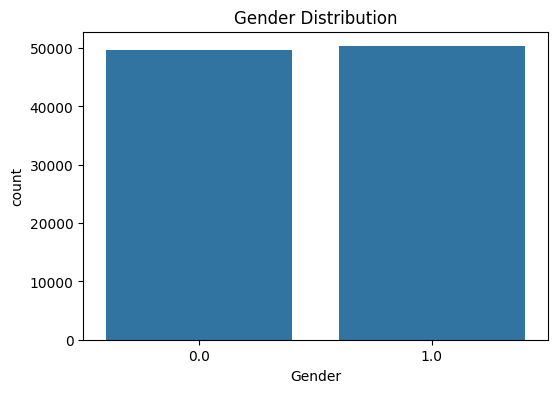

In [17]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df_clean)
plt.title("Gender Distribution")
plt.show()

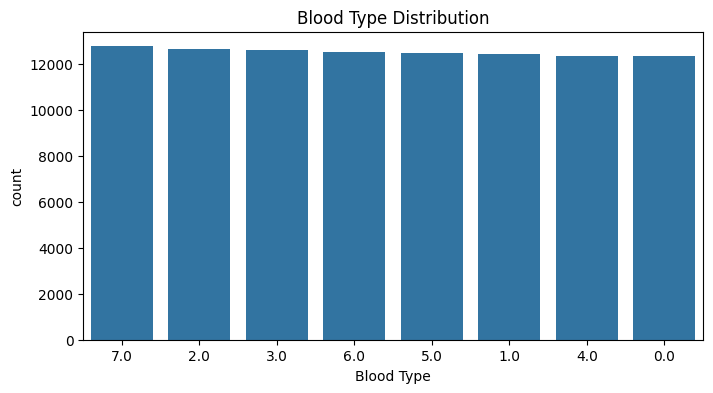

In [18]:
# Blood Type distribution
plt.figure(figsize=(8,4))
sns.countplot(x='Blood Type', data=df_clean, order=df_clean['Blood Type'].value_counts().index)
plt.title("Blood Type Distribution")
plt.show()

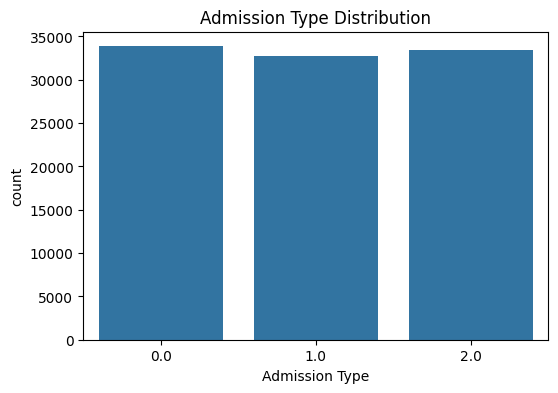

In [19]:
# Admission Type distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Admission Type', data=df_clean)
plt.title("Admission Type Distribution")
plt.show()

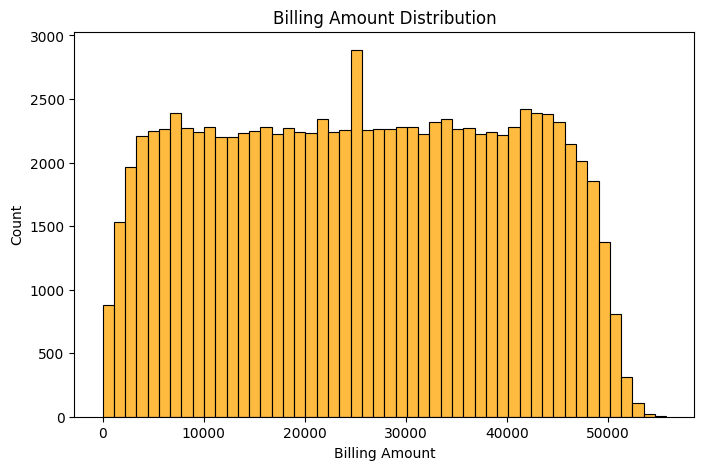

In [20]:
# Billing Amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Billing Amount'], bins=50, color='orange')
plt.title("Billing Amount Distribution")
plt.show()

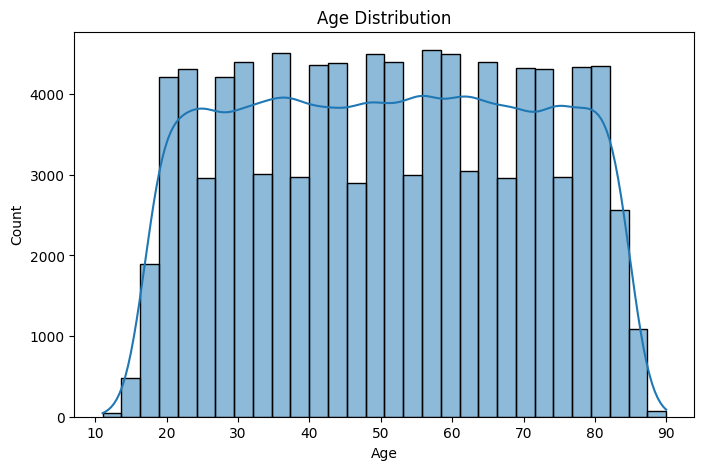

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

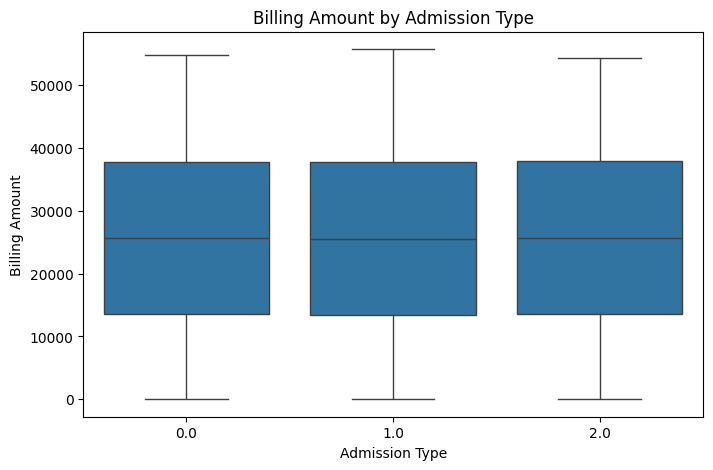

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Admission Type', y='Billing Amount', data=df_clean)
plt.title("Billing Amount by Admission Type")
plt.show()

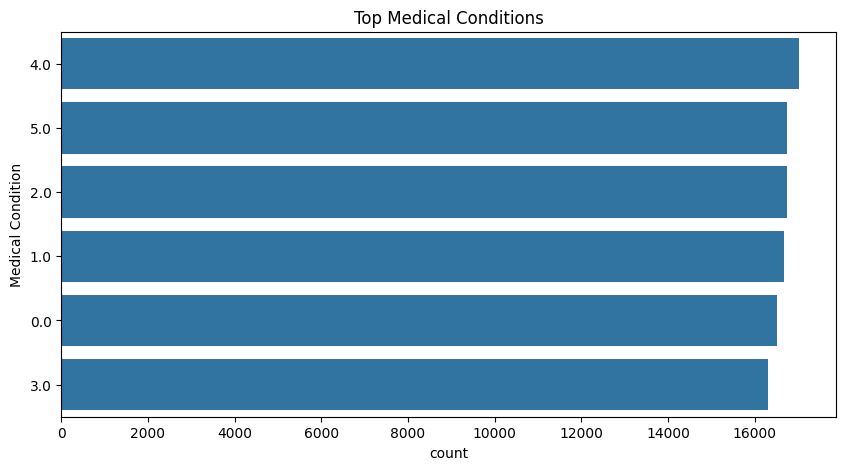

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(y='Medical Condition', 
              data=df_clean, 
              order=df_clean['Medical Condition'].value_counts().index[:10])
plt.title("Top Medical Conditions")
plt.show()